# Data Cleaning

This notebook walks through the data cleaning pipeline for `resume_data.csv`  
and produces `cleaned_resume_data.csv` that is used by both the baseline and primary models.

**Task**: Regression — predict `matched_score` (continuous float, 0–1)  
**Text embeddings**: SBERT (long text) + Word2Vec (skill lists) — applied at model time  
**Missing text**: zero-vector + `has_career_objective` binary flag

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_cleaning import clean_resume_data

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_columns', 40)
%matplotlib inline

## 1. Load raw data and inspect

In [2]:
raw = pd.read_csv('../data/resume_data.csv')
print('Shape:', raw.shape)
raw.head(2)

Shape: (9544, 35)


,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,company_urls,start_dates,end_dates,related_skils_in_job,positions,locations,responsibilities,extra_curricular_activity_types,extra_curricular_organization_names,extra_curricular_organization_links,role_positions,languages,proficiency_levels,certification_providers,certification_skills,online_links,issue_dates,expiry_dates,job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database warehouse manager with robust experi...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Mach...","['The Amity School of Engineering & Technology (ASET), Noida']",['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],[None],['Nov 2019'],['Till Date'],[['Big Data']],['Big Data Analyst'],['N/A'],Technical Support\nTroubleshooting\nCollaboration\nDocumentation\nSystem Mon...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a reputed university.,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaboration\nDocumentation\nSystem Mon...,NaN,0.85
1,NaN,Fresher looking to join as a data analyst and junior data scientist. Experie...,"['Data Analysis', 'Data Analytics', 'Business Analysis', 'R', 'SAS', 'PowerB...","['Delhi University - Hansraj College', 'Delhi University - Hansraj College']","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],['N/A'],['Sep 2019'],['Till Date'],"[['Data Analysis', 'Business Analysis', 'Machine Learning']]",['Business Analyst'],['N/A'],Machine Learning Leadership\nCross-Functional Collaboration\nStrategy Develo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in any relevant discipline from a ...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional Collaboration\nStrategy Develo...,NaN,0.75


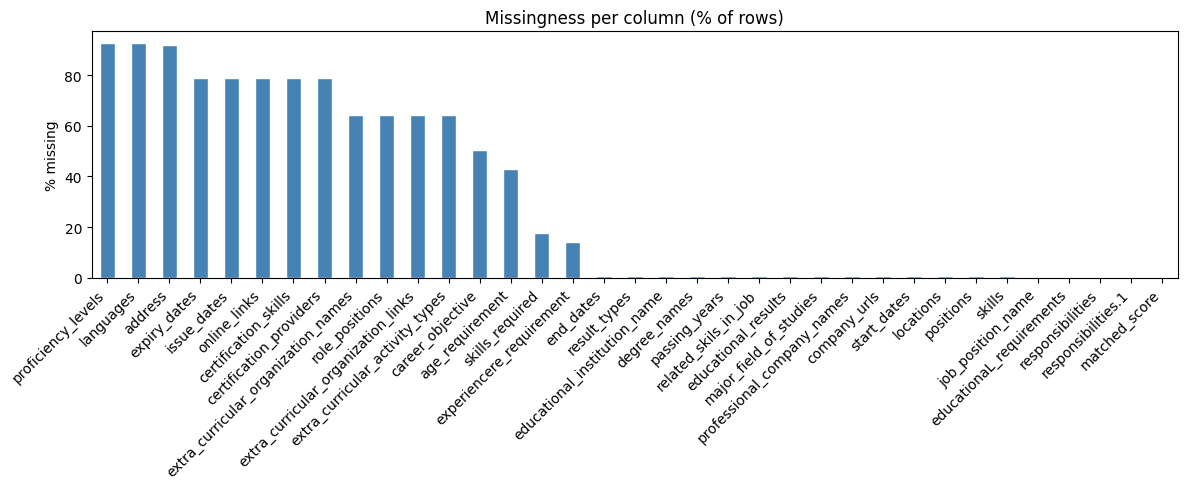

proficiency_levels                     92.7
languages                              92.7
address                                91.8
expiry_dates                           79.0
issue_dates                            79.0
online_links                           79.0
certification_skills                   79.0
certification_providers                79.0
extra_curricular_organization_names    64.1
role_positions                         64.1
extra_curricular_organization_links    64.1
extra_curricular_activity_types        64.1
career_objective                       50.3
age_requirement                        42.8
skills_required                        17.8
experiencere_requirement               14.3
end_dates                               0.9
result_types                            0.9
educational_institution_name            0.9
degree_names                            0.9
passing_years                           0.9
related_skils_in_job                    0.9
educational_results             

In [3]:
# Null counts per column
null_pct = (raw.isnull().sum() / len(raw) * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 5))
null_pct.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Missingness per column (% of rows)')
plt.ylabel('% missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(null_pct.round(1).to_string())

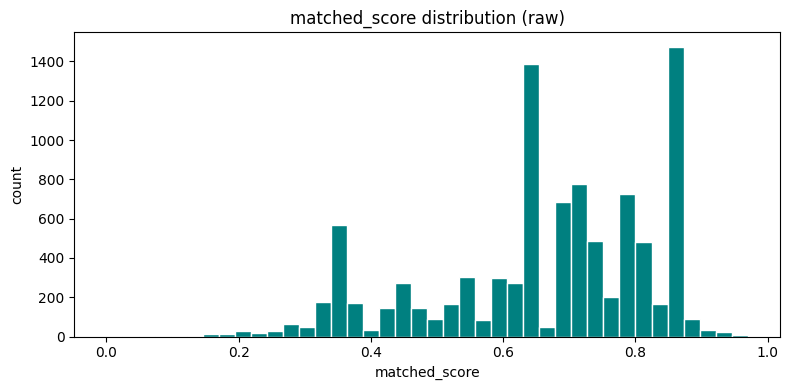

count    9544.000000
mean        0.660831
std         0.167040
min         0.000000
25%         0.583333
50%         0.683333
75%         0.793333
max         0.970000
Name: matched_score, dtype: float64

In [4]:
# Target variable distribution
plt.figure(figsize=(8, 4))
plt.hist(raw['matched_score'].dropna(), bins=40, color='teal', edgecolor='white')
plt.title('matched_score distribution (raw)')
plt.xlabel('matched_score')
plt.ylabel('count')
plt.tight_layout()
plt.show()
raw['matched_score'].describe()

## 2. Run the cleaning pipeline

In [5]:
df = clean_resume_data(
    input_path='../data/resume_data.csv',
    output_path='../data/cleaned_resume_data.csv'
)

Loading ../data/resume_data.csv ...
  Raw shape: (9544, 35)
  Skipping university rankings (no ranking_dir provided or not found).
  Skipping Fortune 100 company features (no companies_csv provided or not found).
  Parsing numerical features ...
  Cleaning text columns ...
  Normalising categorical columns ...
  Cleaned shape: (9544, 27)
  Columns: ['career_objective', 'skills', 'major_field_of_studies', 'related_skils_in_job', 'responsibilities', 'job_position_name', 'educationaL_requirements', 'skills_required', 'matched_score', 'university_rank_score', 'university_world_rank', 'university_is_ranked', 'company_is_fortune100', 'company_fortune100_rank_norm', 'company_size_norm', 'experience_min_years', 'age_min', 'age_max', 'years_since_graduation', 'gpa_normalized', 'total_work_experience_years', 'has_certification', 'num_certifications', 'has_career_objective', 'degree_level', 'result_type', 'most_recent_position']

  Null counts after cleaning:
Series([], dtype: int64)

Saved to ..

## 3. Inspect cleaned data

In [6]:
print('Cleaned shape:', df.shape)
df.head(3)

Cleaned shape: (9544, 27)


,career_objective,skills,major_field_of_studies,related_skils_in_job,responsibilities,job_position_name,educationaL_requirements,skills_required,matched_score,university_rank_score,university_world_rank,university_is_ranked,company_is_fortune100,company_fortune100_rank_norm,company_size_norm,experience_min_years,age_min,age_max,years_since_graduation,gpa_normalized,total_work_experience_years,has_certification,num_certifications,has_career_objective,degree_level,result_type,most_recent_position
0,Big data analytics working and database warehouse manager with robust experi...,big data hadoop hive python mapreduce spark java machine learning cloud hdfs...,electronics,[['Big Data']],Technical Support Troubleshooting Collaboration Documentation System Monitor...,senior software engineer,B.Sc in Computer Science & Engineering from a reputed university.,,0.850000,0.0,0.0,0,0,0.0,0.0,1.0,0.0,0.0,6.0,0.5,6.0,0,0,1,Bachelors,Other,big data analyst
1,Fresher looking to join as a data analyst and junior data scientist. Experie...,data analysis data analytics business analysis r sas powerbi tableau data vi...,mathematics statistics,"[['Data Analysis', 'Business Analysis', 'Machine Learning']]",Machine Learning Leadership Cross-Functional Collaboration Strategy Developm...,machine learning (ml) engineer,M.Sc in Computer Science & Engineering or in any relevant discipline from a ...,,0.750000,0.0,0.0,0,0,0.0,0.0,5.0,0.0,0.0,7.0,0.5,6.0,0,0,1,Masters,Other,business analyst
2,,software development machine learning deep learning risk assessment requirem...,electronics/telecommunication,"[['Unified Payment Interface', 'Risk Prediction', 'Big Data', 'Spark', 'PySp...","Trade Marketing Executive Brand Visibility, Sales Targets Field Marketing, C...","executive/ senior executive- trade marketing, hygiene products",Master of Business Administration (MBA),Brand Promotion Campaign Management Field Supervision Merchandising promotio...,0.416667,0.0,0.0,0,0,0.0,0.0,3.0,0.0,0.0,7.0,0.5,7.0,0,0,0,Bachelors,Other,software developer (machine learning engineer)


In [7]:
# Numeric feature summaries
num_cols = ['experience_min_years', 'age_min', 'age_max', 'years_since_graduation',
            'gpa_normalized', 'total_work_experience_years',
            'has_certification', 'num_certifications', 'has_career_objective',
            'matched_score']
df[num_cols].describe().round(3)

,experience_min_years,age_min,age_max,years_since_graduation,gpa_normalized,total_work_experience_years,has_certification,num_certifications,has_career_objective,matched_score
count,9544.000,9544.000,9544.000,9544.000,9544.000,9544.000,9544.000,9544.000,9544.000,9544.000
mean,3.036,13.581,25.159,8.924,0.562,11.808,0.210,0.354,0.497,0.661
std,2.910,12.092,23.965,8.470,0.153,11.554,0.408,1.194,0.500,0.167
min,0.000,0.000,0.000,0.000,0.080,0.000,0.000,0.000,0.000,0.000
25%,1.000,0.000,0.000,5.000,0.500,3.000,0.000,0.000,0.000,0.583
50%,3.000,18.000,30.000,6.000,0.500,6.000,0.000,0.000,0.000,0.683
75%,5.000,25.000,40.000,11.000,0.500,19.000,0.000,0.000,1.000,0.793
max,15.000,30.000,65.000,47.000,1.000,50.000,1.000,18.000,1.000,0.970


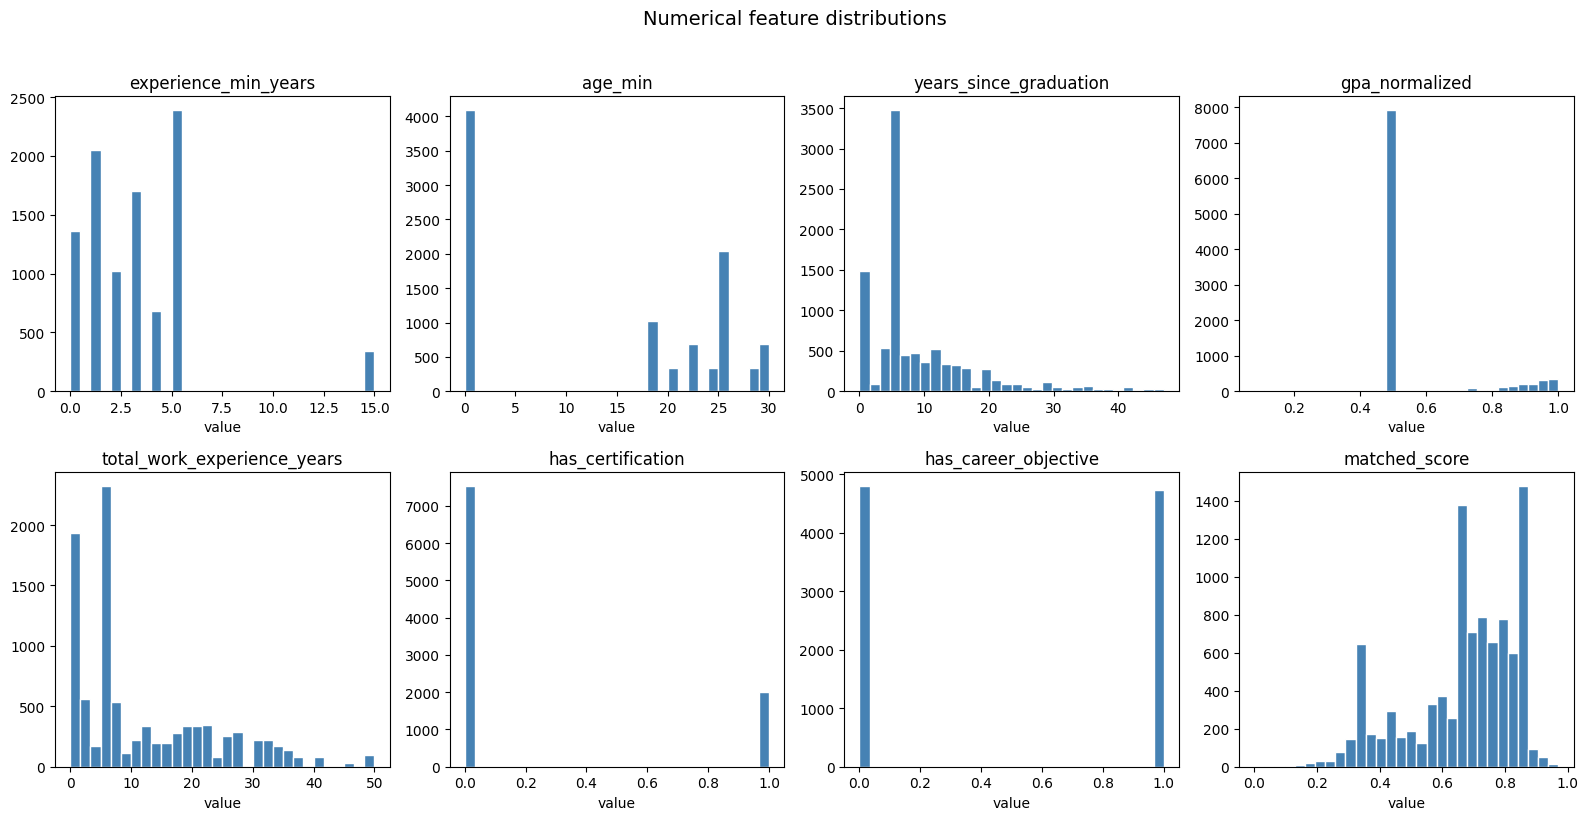

In [8]:
# Distribution plots for numerical features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(['experience_min_years', 'age_min', 'years_since_graduation',
                          'gpa_normalized', 'total_work_experience_years',
                          'has_certification', 'has_career_objective', 'matched_score']):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('value')
plt.suptitle('Numerical feature distributions', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

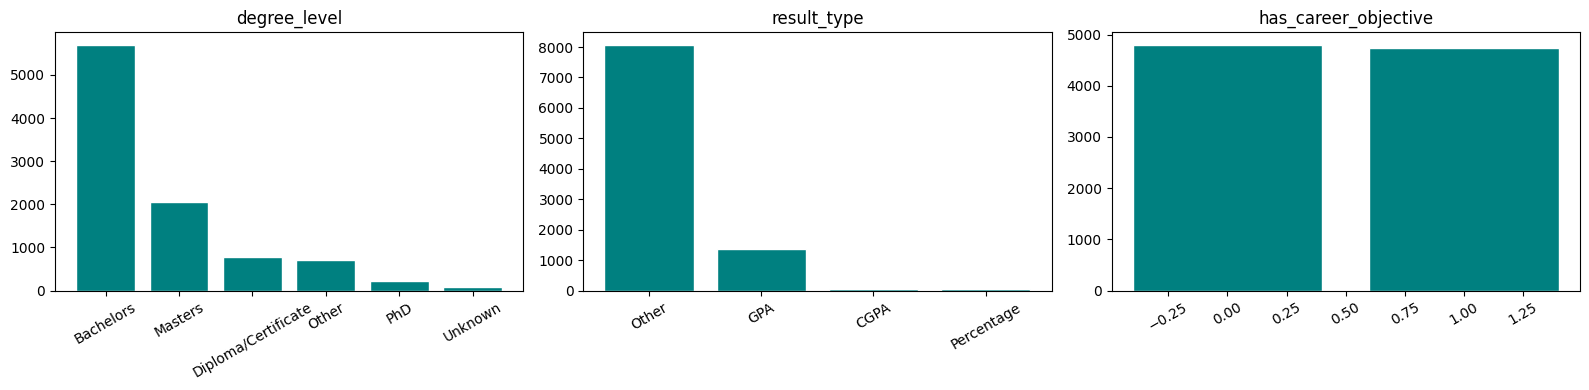

In [9]:
# Categorical distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['degree_level', 'result_type', 'has_career_objective']):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color='teal', edgecolor='white')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

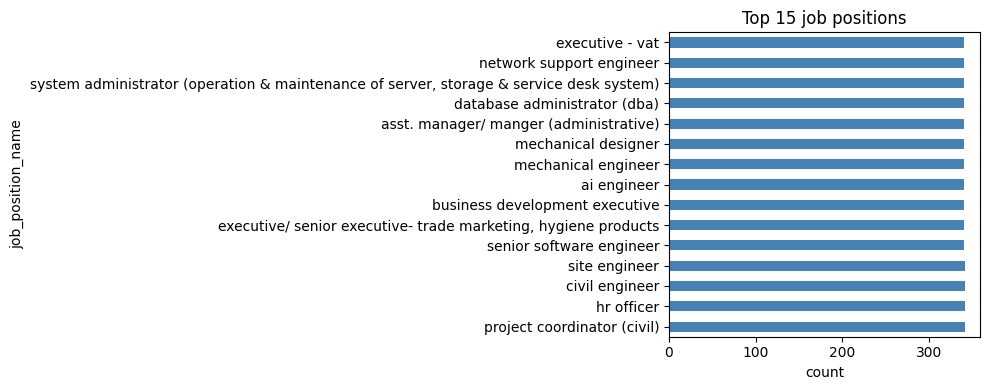

In [10]:
# Top job positions
top_jobs = df['job_position_name'].value_counts().head(15)
plt.figure(figsize=(10, 4))
top_jobs.plot(kind='barh', color='steelblue')
plt.title('Top 15 job positions')
plt.xlabel('count')
plt.tight_layout()
plt.show()

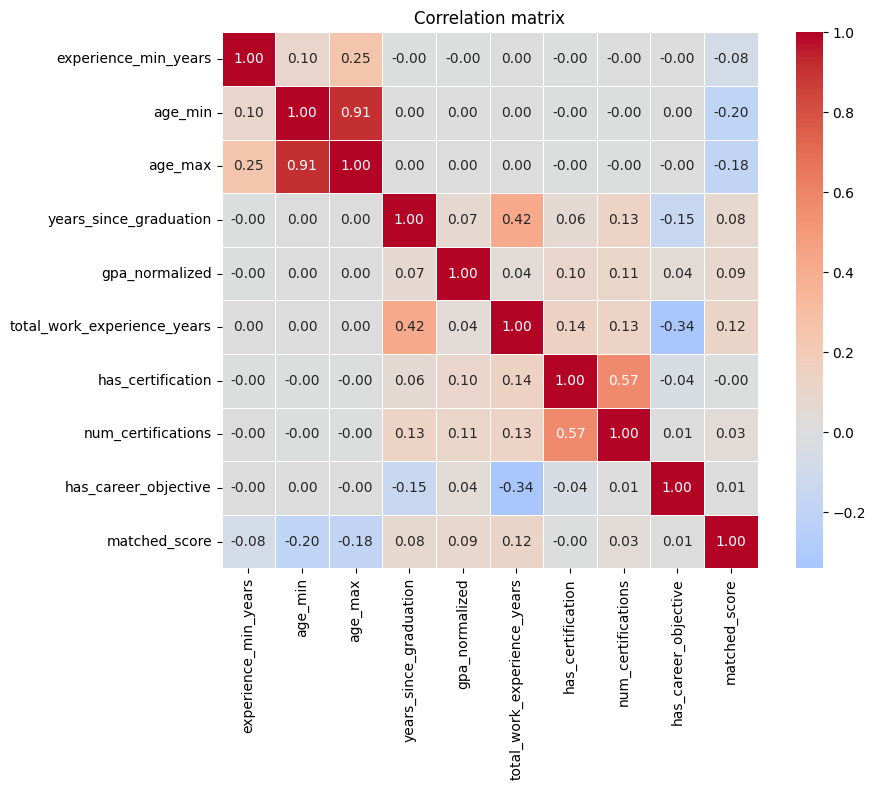

In [11]:
# Correlation heatmap for numeric features
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

## 3b. GPA Normalization — Transformation Mapping

The raw `educational_results` column contains GPA data in at least **6 distinct formats**:
- `"3.5 out of 4.0"` — explicit fraction  
- `"85%"` — percentage  
- `"3.8"` — bare number (heuristic: ≤4.0 → GPA/4, ≤5.0 → GPA/5, >10 → treated as %)
- `"N/A"` / missing — imputed to **0.5** (neutral midpoint) + `has_career_objective` flag carries the signal

All formats are normalized to **[0, 1]** using format-specific rules. The plot below maps the transformation.

In [ ]:

# ─── GPA Normalization — 3-panel Transformation Mapping ──────────────────────
import re, ast
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Publication style (fonts scaled 1.5×)
rcParams.update({
    'font.family': 'DejaVu Sans', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 16,   # 11 × 1.5
    'axes.titlesize': 18,   # 12 × 1.5
    'xtick.labelsize': 14,  #  9 × 1.5
    'ytick.labelsize': 14,  #  9 × 1.5
})

PALETTE = {
    "X out of Y":              "#4C72B0",
    "Percentage (%)":          "#DD8452",
    "Bare number ≤4":          "#55A868",
    "Bare number 4–5":         "#C44E52",
    "Bare number 5–10 (CGPA)": "#E377C2",
    "Bare number >10":         "#8172B2",
    "N/A (imputed 0.5)":       "#AAAAAA",
}
FMT_ORDER = list(PALETTE.keys())

# ── Re-classify each raw educational_results entry (mirrors data_cleaning.py) ─
def _safe_parse_nb(val):
    if pd.isna(val) or str(val).strip() == "":
        return []
    try:
        r = ast.literal_eval(str(val))
        return [str(x).strip() for x in r] if isinstance(r, list) else [str(r).strip()]
    except Exception:
        return [x.strip().strip("'\"[]") for x in str(val).split(",") if x.strip()]

def _classify_val(val):
    """Returns (raw_fraction, gpa_norm, format_label) for the first parseable entry."""
    if pd.isna(val):
        return None, 0.5, "N/A (imputed 0.5)"
    for item in _safe_parse_nb(val):
        s = str(item).lower().strip()
        m = re.search(r"([\d.]+)\s*out\s*of\s*([\d.]+)", s)
        if m:
            num, denom = float(m.group(1)), float(m.group(2))
            if denom > 0:
                rf = min(num / denom, 1.0)
                return rf, rf, "X out of Y"
            continue
        m = re.search(r"([\d.]+)\s*%", s)
        if m:
            rf = min(float(m.group(1)) / 100.0, 1.0)
            return rf, rf, "Percentage (%)"
        m = re.search(r"\d[\d.]*\d|\d", s)
        if m:
            v = float(m.group(0))
            if v > 10:
                return min(v / 100.0, 1.0), min(v / 100.0, 1.0), "Bare number >10"
            elif v <= 4.0:
                return v / 4.0, v / 4.0, "Bare number ≤4"
            elif v <= 5.0:
                return v / 5.0, v / 5.0, "Bare number 4–5"
            else:            # 5 < v ≤ 10: CGPA out of 10 (fixed)
                return v / 10.0, v / 10.0, "Bare number 5–10 (CGPA)"
    return None, 0.5, "N/A (imputed 0.5)"

records = [_classify_val(v) for v in raw["educational_results"]]
rdf = pd.DataFrame(records, columns=["raw_fraction", "gpa_norm", "format_type"])

fmt_counts = (rdf["format_type"]
              .value_counts()
              .reindex(FMT_ORDER)
              .fillna(0)
              .astype(int))
is_imputed  = rdf["format_type"] == "N/A (imputed 0.5)"
parsed_mask = ~is_imputed
n_imp = int(is_imputed.sum())

# ─── Figure ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("GPA Normalization — How Raw Values Map to a 0–1 Scale",
             fontsize=21, fontweight='bold', y=1.01)

# ── Panel 1: Format-type distribution ────────────────────────────────────────
ax = axes[0]
vals = fmt_counts.values
lbls = fmt_counts.index.tolist()
cols = [PALETTE[l] for l in lbls]
bars = ax.barh(lbls, vals, color=cols, edgecolor='white', height=0.65)
ax.invert_yaxis()
ax.set_xlabel("Number of rows")
ax.set_title("① Format-Type Distribution")
for bar, cnt in zip(bars, vals):
    if cnt > 0:
        ax.text(bar.get_width() + 40, bar.get_y() + bar.get_height() / 2,
                f'{cnt:,}', va='center', fontsize=14)
ax.set_xlim(0, vals.max() * 1.22)

# ── Panel 2: Transformation mapping scatter ───────────────────────────────────
ax = axes[1]
parsed = rdf[parsed_mask].dropna(subset=["raw_fraction"])
for fmt in FMT_ORDER[:-1]:               # skip imputed in scatter
    sub = parsed[parsed["format_type"] == fmt]
    if len(sub):
        ax.scatter(sub["raw_fraction"], sub["gpa_norm"],
                   s=14, alpha=0.30, color=PALETTE[fmt], label=fmt, linewidths=0)
ax.plot([0, 1], [0, 1], 'k--', lw=1.3, alpha=0.55, label='y = x (identity)', zorder=5)
# Imputed 0.5 band
ax.axhspan(0.463, 0.537, color=PALETTE["N/A (imputed 0.5)"], alpha=0.22, zorder=0)
ax.axhline(0.5, color='#888888', lw=1.0, ls=':', zorder=0)
ax.text(0.03, 0.515, f'Imputed 0.5  (n = {n_imp:,})',
        fontsize=12, color='#555555', va='bottom')
ax.set_xlim(-0.02, 1.05)
ax.set_ylim(-0.02, 1.05)
ax.set_xlabel("Raw fraction  (extracted value ÷ denominator)")
ax.set_ylabel("gpa_normalized output")
ax.set_title("② Transformation: Raw Fraction → Normalized GPA")
ax.legend(fontsize=12, loc='upper left', framealpha=0.88, markerscale=2)

# ── Panel 3: Final distribution — imputed vs parsed ──────────────────────────
ax = axes[2]
bins = np.arange(0, 1.021, 0.020)
parsed_gpa  = rdf.loc[parsed_mask, "gpa_norm"].values
imputed_gpa = rdf.loc[is_imputed,  "gpa_norm"].values
ax.hist(parsed_gpa,  bins=bins, color="#4C72B0", alpha=0.75,
        label=f"Parsed   (n = {len(parsed_gpa):,})", edgecolor='white', zorder=2)
ax.hist(imputed_gpa, bins=bins, color="#AAAAAA", alpha=0.90,
        label=f"Imputed 0.5  (n = {len(imputed_gpa):,})", edgecolor='white', zorder=3)
ax.axvline(0.5, color='#CC3333', lw=1.5, ls='--', alpha=0.75, zorder=4)
ax.set_xlabel("gpa_normalized")
ax.set_ylabel("Count")
ax.set_title("③ Final Distribution (parsed vs imputed)")
ax.legend(fontsize=14, loc='upper left')

plt.tight_layout()
plt.savefig("../data/gpa_normalization_plot.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Format breakdown:\n{fmt_counts[fmt_counts > 0].to_string()}")
print(f"\nTotal: {len(rdf):,}  |  Parsed: {parsed_mask.sum():,}  |  Imputed 0.5: {n_imp:,}")


In [12]:
# Sample cleaned training example
sample = df.iloc[0]
for col in df.columns:
    val = sample[col]
    if isinstance(val, str) and len(val) > 100:
        val = val[:100] + '...'
    print(f'{col:35s}: {val}')

career_objective                   : Big data analytics working and database warehouse manager with robust experience in handling all kin...
skills                             : big data hadoop hive python mapreduce spark java machine learning cloud hdfs yarn core java data sci...
major_field_of_studies             : electronics
related_skils_in_job               : [['Big Data']]
responsibilities                   : Technical Support Troubleshooting Collaboration Documentation System Monitoring Software Deployment ...
job_position_name                  : senior software engineer
educationaL_requirements           : B.Sc in Computer Science & Engineering from a reputed university.
skills_required                    : 
matched_score                      : 0.85
university_rank_score              : 0.0
university_world_rank              : 0.0
university_is_ranked               : 0
company_is_fortune100              : 0
company_fortune100_rank_norm       : 0.0
company_size_norm             

## 4. Column Fate Summary

| Category | Columns | Fate |
|---|---|---|
| **Dropped** | address, company_urls, online_links, responsibilities.1, professional_company_names, educational_institution_name, certification_providers, issue_dates, expiry_dates, languages, proficiency_levels, extra_curricular_* | Too many nulls / URL / duplicate |
| **Numerical** | experiencere_requirement → experience_min_years, age_requirement → age_min/age_max, passing_years → years_since_graduation, educational_results → gpa_normalized, start/end_dates → total_work_experience_years | Parsed from messy strings |
| **Binary flags** | career_objective → has_career_objective, certification_skills → has_certification | Missingness signal |
| **Text** | career_objective, skills, responsibilities, skills_required, educationaL_requirements, related_skils_in_job, major_field_of_studies | Cleaned; embedded at model time |
| **Categorical** | job_position_name, degree_level, result_type, most_recent_position | Normalized; one-hot at model time |
| **Target** | matched_score | Unchanged (continuous 0–1) |